<div style="max-width:300px; float: left; margin-right: 1em">

![](Figures/fcfm_das.svg)

</div>
<span style="color: red;">Departamento de Astronomía, Universidad de Chile</span> <br>
Facultad de Ciencias Físicas y Matemáticas <br>
Universidad de Chile <br>
AS4501 - Astroinformatica <br>
Otoño 2026 <br>
Profesor: Francisco Förster Burón <br>
<strong>Profesores Auxilares y Autores: Benjamin Carrera y Steve Jurado</strong> <br>

> This notebook is created based on the notes from 
> - ([@fforster](https://github.com/fforster)) Francisco Förster: - **Main Notes 2026/01**   
>   - https://github.com/fforster/AS4501/tree/main
> - ([@thevalentino](https://github.com/thevalentino)) Valentino Gonzales:
>   - https://github.com/thevalentino/AS450-astroinformatica
> - ([@cefuente](https://github.com/cefuente)) Cesar Fuentes
>   - https://github.com/cefuente/astroinformatica
> and previour teachers assistants
> - ([@m-fuentealba](https://github.com/m-fuentealba)) Melissa Fuentealba 
> - ([@jvines](https://github.com/jvines)) José Vines
> - ([@PauCaBu](https://github.com/PauCaBu)) Paula Cáceres Burgos
> - ([@JavieraTGrey](https://github.com/JavieraTGrey)) Javiera Toro Grey

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
try:
   from astropy.table import vstack
except:
   !pip install astropy
   from astropy.table import vstack
try:
   from astroquery.gaia import Gaia
except:
   !pip install astroquery
   from astroquery.gaia import Gaia

color_classes = {'RR': 'C0', 'CEP': 'C1', 'DSCT': 'C2'}

rc_params = {
    # --- Fonts and text ---
    'mathtext.fontset': 'cm',     # Set default mathtext font
    'font.family': 'STIXGeneral', # Set default font family
    
    # --- Figure and axes ---
    'font.size': 12,              # Set default font size
    'axes.labelsize': 16,         # Set default axes label size
    'axes.titlesize': 16,         # Set default axes title size
    'xtick.labelsize': 14,        # Set default axes label size
    'ytick.labelsize': 14,        # Set default axes label size
    'legend.fontsize': 14,        # Set default legend font size
    
    # --- Configuration of ticks ---
    'xtick.direction': 'in',      # Set default xtickdirecion
    'ytick.direction': 'in',      # Set default ytickdirecion
    'xtick.minor.visible': True,  # visibility of minor ticks on x-axis
    'ytick.minor.visible': True,  # visibility of minor ticks on y-axis


    'grid.linestyle': ':',        # Set grid linestyle
    'grid.alpha': 0.6,            # Set grid transparency
    
    # --- Figure size ---
    'figure.figsize': (8, 6),     # Proporción ideal para una columna de MNRAS
}
plt.rcParams.update(rc_params)

The archive is unstable and may perform below expectations. If launching multiple, consecutive, heavy queries through Python, please space them out (e.g., using sleep(1)) to avoid overloading the system. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the December 2025 infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive

The GACS will be under maintenance on 15 April from 11:00 to 13:00 CEST approximately, for the upgrade to version 3.12.0. Apologies for the inconveniences.


In this project, we utilize data from Gaia DR3 to perform a classification task on Variable Stars. These are celestial objects that exhibit fluctuations in their luminosity over time.

We focus on the three most common types found in the Gaia catalogs:

- **Cepheids (CEP):** High-mass, highly luminous stars (giants and supergiants). They occupy the upper section of the instability strip in the HR diagram.

- **RR Lyrae (RR):** Older, low-mass stars. They are less luminous than Cepheids and are typically found on the "Horizontal Branch."

- **Delta Scuti (DSCT):** Stars located on the Main Sequence or slightly evolved from it. They exhibit lower luminosity compared to the previous classes and higher frequencies in their pulsations.

![](Figures/hr_diagram_variable_stars.png)

In [2]:
n_samples = 500 
tables = []
classes = ['RR', 'CEP', 'DSCT|GDOR|SXPHE']

for cls in classes:
    print(f"\n[1] Iniciando consulta para: {cls}...")
    
    q = f"""
    SELECT TOP {n_samples}
        g.source_id, g.ra, g.dec, g.parallax, g.pmra, g.pmdec,
        g.phot_g_mean_mag, g.bp_rp,
        v.best_class_name AS target_class
    FROM gaiadr3.gaia_source AS g
    JOIN gaiadr3.vari_classifier_result AS v
        ON g.source_id = v.source_id
    WHERE g.parallax_over_error > 5
        AND g.bp_rp IS NOT NULL
        AND v.best_class_name = '{cls}'
    ORDER BY g.random_index
    """
    
    # Forzamos una limpieza de caché en caso de que astroquery haya guardado un error previo
    job = Gaia.launch_job_async(q)
    t = job.get_results()
    
    # AUDITORÍA DE DESCARGA
    print(f" -> Filas descargadas desde Gaia: {len(t)}")
    
    if len(t) > 0:
        tables.append(t)

print("\n[2] Apilando tablas (vstack)...")
results = vstack(tables)

# Convertimos a Pandas
df = results.to_pandas()

# Replace the target_class values to more general categories
df.replace({'target_class': {
    'RR': 'RR',
    'CEP': 'CEP',
    'DSCT|GDOR|SXPHE': 'DSCT',
}}, inplace=True)


[1] Iniciando consulta para: RR...


INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 500

[1] Iniciando consulta para: CEP...
INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 500

[1] Iniciando consulta para: DSCT|GDOR|SXPHE...
INFO: Query finished. [astroquery.utils.tap.core]
 -> Filas descargadas desde Gaia: 500

[2] Apilando tablas (vstack)...


,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,target_class
0,5249397097487396480,145.556248,-64.372945,0.262521,0.457533,4.827408,14.321663,0.787969,RR
1,2740035546817737472,0.838283,3.397805,0.269619,-10.473504,-7.696569,13.567632,0.620358,RR
2,6569534598179733888,336.584291,-40.991329,0.152301,2.090410,3.432126,14.306556,0.652573,RR
3,2912666916856166144,93.843949,-23.740869,0.118174,1.410377,0.364509,14.624155,0.681923,RR
4,4037930034749650048,272.901024,-36.524699,0.213557,-9.382456,0.064918,14.347184,0.777572,RR
...,...,...,...,...,...,...,...,...,...
1495,5341244698251340416,165.577258,-54.781317,0.983594,-12.695808,6.935109,12.698147,0.435057,DSCT
1496,5935366871469261568,246.573754,-49.777189,1.259307,-1.809740,-2.161345,12.662856,0.585512,DSCT
1497,3030249377530960256,113.973176,-13.987027,0.802282,-0.300922,-0.201252,13.325069,0.506811,DSCT
1498,1979076232293617408,323.828916,49.422375,1.512684,4.146544,0.742019,8.944630,0.062808,DSCT


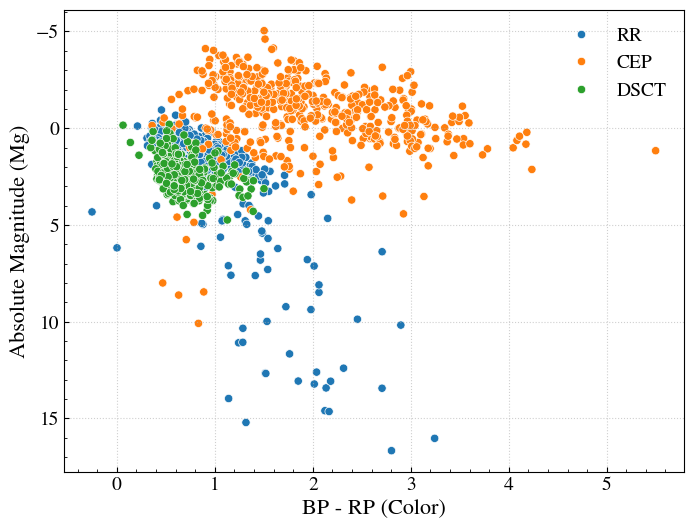

In [3]:
# Absolute Magnitude (Mg)
# Mg = G + 5 * log10(parallax) - 10
df['Mg'] = df['phot_g_mean_mag'] + 5 * np.log10(df['parallax']) - 10

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='bp_rp',
    y='Mg',
    hue='target_class',
    color=df['target_class'].map(color_classes)
)
ax.invert_yaxis()
ax.set_xlabel('BP - RP (Color)')
ax.set_ylabel('Absolute Magnitude (Mg)')
ax.legend(title='', frameon=False)
ax.grid()
plt.show()

In [4]:
# Forzamos la columna target_class a string estándar (a veces Astropy la deja como bytes tipo b'CEP')
df['target_class'] = df['target_class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

print(f" -> Tamaño del DataFrame crudo: {df.shape[0]} filas.")
print(df['target_class'].value_counts())

print("\n[4] Mezclando datos (shuffle)...")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nDistribución final de clases lista para Machine Learning:")
print(df['target_class'].value_counts())

 -> Tamaño del DataFrame crudo: 1500 filas.
target_class
RR      500
CEP     500
DSCT    500
Name: count, dtype: int64

[4] Mezclando datos (shuffle)...

Distribución final de clases lista para Machine Learning:
target_class
DSCT    500
RR      500
CEP     500
Name: count, dtype: int64


We will begin with the classification task. First we need to defined a train and test dataset. For this we will use the library `sklearn`

## $K$-Nearest Neighbors (KNN)

The K-Nearest Neighbors (KNN) algorithm is a non-parametric supervised learning method used for classification. In the context of variable stars, the algorithm predicts the class of a target star by analyzing its $k$ closest neighbors within a multidimensional feature space (e.g., color, absolute magnitude, and parallax).

Given a labeled training set $\{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$, KNN classifies a new point $\mathbf{x}$ by finding its $k$ closest neighbors under a distance metric typically the Euclidean distance:

$$d(\mathbf{x}, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{p}(x_j - x_{i,j})^2}$$

The predicted class is the **majority vote** among the $k$ nearest neighbors:

$$\hat{y} = \underset{c}{\arg\max} \sum_{i \in \mathcal{N}_k(\mathbf{x})} \mathbf{1}[y_i = c]$$

where $\mathcal{N}_k(\mathbf{x})$ is the set of the $k$ closest points to $\mathbf{x}$

To improve performance in regions where stellar populations overlap, we can assign a weight $w_i$ to each neighbor inversely proportional to its distance:$$w_i = \frac{1}{d(\mathbf{x}, \mathbf{x}_i)^2}$$This ensures that more "similar" stars have a greater influence on the classification than those at the outskirts of the $k$-neighborhood.

**Effect of $k$:**
- Small $k$ → Low bias, high variance. The model is sensitive to noise (e.g., photometric errors in Gaia DR3) and outliers.
- Large $k$ → High bias, low variance. It produces smoother decision boundaries but may overlook small-scale structures in the instability strip.

> **Important:** KNN is highly sensitive to the scale of input features. Because the algorithm relies on distance metrics to identify neighbors, features with larger numerical ranges will disproportionately dominate the calculation.
> If one feature (e.g., $G$ magnitude) ranges from $10$ to $20$ and another (e.g., parallax) ranges from $0.001$ to $0.01$, the magnitude difference will numerically overwhelm the parallax difference, effectively "blinding" the model to the astrometric data.
> To mitigate this, we use Standardization (Z-score normalization). This transforms the data so that each feature has a mean ($\mu$) of $0$ and a standard deviation ($\sigma$) of $1$:
> $$z = \frac{x - \mu}{\sigma}$$
> `from sklearn.preprocessing import StandardScaler`
> `scaler = StandardScaler()`
> `X_train_scaled = scaler.fit_transform(X_train)`
> `X_test_scaled = scaler.transform(X_test)`
> `knn.fit(X_train_scaled, y_train)`

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


# First we select the physical features that we will use for the classification
# In this case, we will as features Mg, bp_rp, parallax, pmra, pmdec and as target the
# target_class.

X = df[['Mg', 'bp_rp', 'parallax', 'pmra', 'pmdec']]
y = df['target_class']

# Lets split the data into training and testing sets, using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now we will create a KNN classifier and fit it to the training data
k = 5 # Number of neighbors
knn   = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

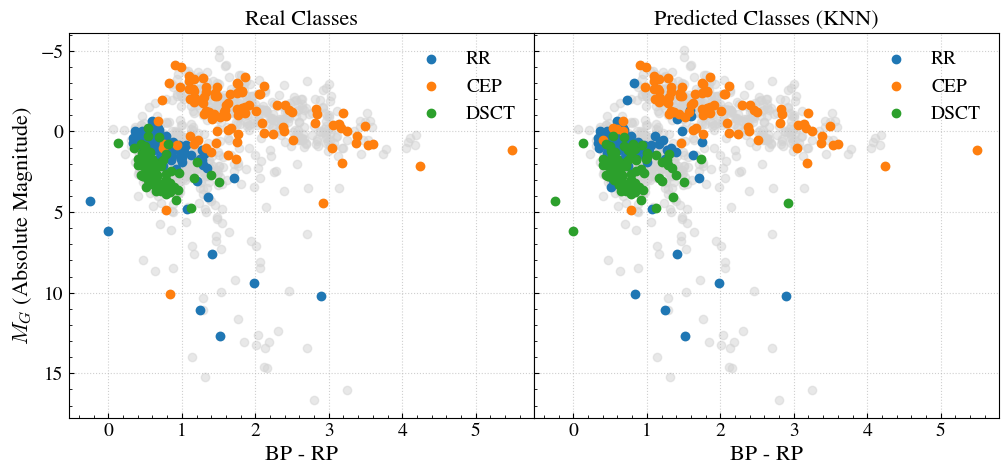

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True, gridspec_kw={'wspace': 0})

for ax, labels, title in zip(axes,
                              [y_test, y_pred],
                              ['Real Classes', 'Predicted Classes (KNN)']):

    # ── Fondo gris: muestra completa original ──────────────────
    ax.scatter(df['bp_rp'], df['Mg'],c='lightgray',  alpha=0.5, zorder=1)

    # ── Puntos coloreados del test set ─────────────────────────
    for cls, color in color_classes.items():
        mask = labels == cls
        ax.scatter(X_test.loc[mask, 'bp_rp'],
                   X_test.loc[mask, 'Mg'],
                   c=color, label=cls, zorder=2)

    ax.set_xlabel('BP - RP')
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.grid()

axes[0].invert_yaxis()
axes[0].set_ylabel('$M_G$ (Absolute Magnitude)')

plt.show()

A powerful way to visually assess classifier performance is the **confusion matrix**. For a problem with $C$ classes, it is a $C \times C$ matrix $\mathbf{M}$ where each entry $M_{ij}$ counts the number of samples whose **true class is $i$** and were **predicted as class $j$**:

The diagonal entries $M_{ii}$ represent **correct classifications**, while off-diagonal entries reveal **where and how the model confuses classes**.

Reading the matrix:
- A **dark diagonal** → the model separates classes well
- A bright off-diagonal cell $M_{ij}$ → the model systematically confuses class $i$ for class $j$

In our three-class problem (CEP, RR Lyrae, DSCT), the confusions have distinct physical interpretations:

- **CEP ↔ RR Lyrae:** Both are radially pulsating stars lying within the classical instability strip. Their period–luminosity sequences overlap at short periods, making photometric separation challenging.
- **CEP ↔ DSCT:** Cepheids are evolved supergiants, while Delta Scuti stars are main-sequence A–F stars.Confusion here suggests the model is not effectively using the absolute magnitude $M_G$ (parallax-derived luminosity).
- **RR ↔ DSCT:** RR Lyrae are old, metal-poor horizontal branch stars, while DSCT are young Population I stars. Confusion in this pair would indicate poor use of color ($BP-RP$) or proper motion features

`sklearn` provides two convenient tools to compute and display it.

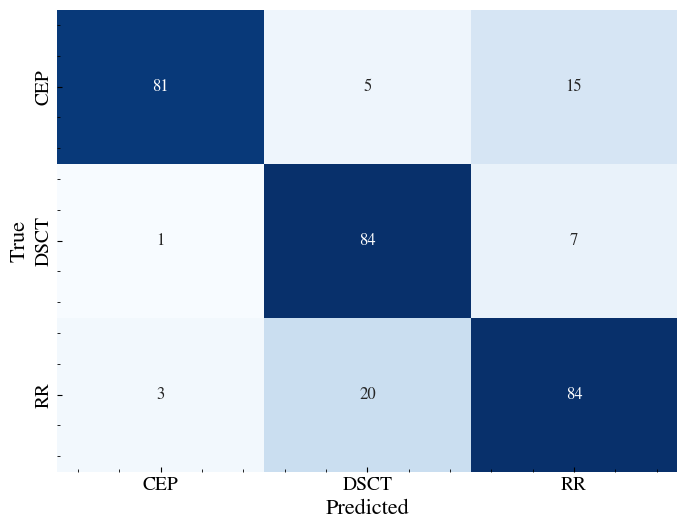

In [7]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots()
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_, cbar=False, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.show()

We now compute the standard classification metrics: precision, recall, F1-score, and accuracy. For a given class $c$, we define:

- **True Positives (TP):** samples of class $c$ correctly predicted as $c$
- **False Positives (FP):** samples of other classes incorrectly predicted as $c$
- **False Negatives (FN):** samples of class $c$ incorrectly predicted as another class
- **True Negatives (TN):** samples not of class $c$ correctly predicted as not $c$

The metrics are then defined as:
- **Precision (Purity):** Precision measures the accuracy of positive predictions. It answers: Of all stars flagged as class $c$, how many actually belong to it?
    $$\text{Precision} = \frac{TP}{TP + FP}$$
    High Precision indicates a "clean" sample with low contamination from other stellar types.

- **Recall (Completeness / Sensitivity):** Recall measures the ability of the model to find all instances of a class. It answers: Of all actual stars of class $c$ in the dataset, how many did the model correctly identify?
    $$\text{Recall} = \frac{TP}{TP + FN}$$
    High Recall is crucial when the goal is to create an exhaustive catalog of a specific variability type.

- **F1-Score:** The F1-score is the harmonic mean of Precision and Recall. It provides a single score that balances both metrics, which is particularly useful when dealing with imbalanced classes (e.g., when Cepheids are much rarer than Delta Scuti stars).
    $$\text{F1-score} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2\,TP}{2\,TP + FP + FN}$$

- **Accuracy (Exactitude):** Accuracy represents the proportion of total correct predictions across all classes.
    $$\text{Accuracy} = \frac{\sum_c TP_c}{N} = \frac{\text{correctly classified samples}}{\text{total samples}}$$
    Accuracy can be misleading if the dataset is highly imbalanced, as a model could achieve high accuracy by simply predicting the majority class.


For CEP — $TP=81,\ FP=1+3=4,\ FN=5+15=20$

$$\text{Precision}_{CEP} = \frac{81}{81+4} = \frac{81}{85} \approx 0.953$$

$$\text{Recall}_{CEP} = \frac{81}{81+20} = \frac{81}{101} \approx 0.802$$

$$\text{F1}_{CEP} = \frac{2\times81}{2\times81+4+20} = \frac{162}{186} \approx 0.871$$

For DSCT — $TP=84,\ FP=5+20=25,\ FN=1+7=8$

$$\text{Precision}_{DSCT} = \frac{84}{84+25} = \frac{84}{109} \approx 0.771$$

$$\text{Recall}_{DSCT} = \frac{84}{84+8} = \frac{84}{92} \approx 0.913$$

$$\text{F1}_{DSCT} = \frac{2\times84}{2\times84+25+8} = \frac{168}{201} \approx 0.836$$

For RR — $TP=84,\ FP=15+7=22,\ FN=3+20=23$

$$\text{Precision}_{RR} = \frac{84}{84+22} = \frac{84}{106} \approx 0.792$$

$$\text{Recall}_{RR} = \frac{84}{84+23} = \frac{84}{107} \approx 0.785$$

$$\text{F1}_{RR} = \frac{2\times84}{2\times84+22+23} = \frac{168}{213} \approx 0.789$$





For multi-class problems (as in our case: RR, CEP, DSCT/GDOR/SXPHE), these metrics are computed **per class** and then averaged. `classification_report` uses **macro averaging** by default:

$$\overline{\text{F-1}} = \frac{1}{C} \sum_{c=1}^{C} \text{F-1}_c$$

where $C$ is the number of classes.
skelarn tiene dentro de su mismo código una forma calcular las metricas por si mismo a través de moetodo

from sklearn.metrics import classification_report

In [8]:
# Finally, we will evaluate the performance of the classifier on the test set
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         CEP       0.95      0.80      0.87       101
        DSCT       0.77      0.91      0.84        92
          RR       0.79      0.79      0.79       107

    accuracy                           0.83       300
   macro avg       0.84      0.83      0.83       300
weighted avg       0.84      0.83      0.83       300



## ROC Curve (Receiver Operating Characteristic)
The ROC Curve is a diagnostic tool used to visualize the performance of a binary (or multi-class One-vs-Rest) classifier as the decision threshold ($\tau$) varies.In a KNN model, classification is based on local proportions. For example, if you set $k=10$ and 7 neighbors belong to the 'CEP' class, the model assigns a probability of $0.7$ to that class.If your threshold is $\tau = 0.5$, the star is classified as 'CEP'.If you raise the threshold to $\tau = 0.8$, the same star would be classified as "Other."The ROC curve is generated by calculating the following metrics across all possible thresholds between 0 and 1:$$TPR = \frac{TP}{TP+FN} \qquad FPR = \frac{FP}{FP+TN}$$TPR (True Positive Rate / Sensitivity): The proportion of actual positives correctly identified.FPR (False Positive Rate): The proportion of actual negatives incorrectly identified as positives.

**AUC (Area Under the Curve):** The AUC is a scalar value that summarizes the overall performance displayed in the ROC plot. Mathematically, it represents the probability that the model will rank a randomly chosen positive instance higher than a randomly chosen negative one.It is calculated as the integral of the ROC curve:
$$AUC = \int_{0}^{1} TPR(FPR) \, dFPR$$
Interpretation of Values:
- $AUC = 1.0$: A perfect classifier. It achieves total separation between classes with zero overlap.
- $0.7 < AUC < 0.9$: A robust model with high discriminative power.
- $AUC = 0.5$: A random classifier (equivalent to a coin flip). This is represented by the diagonal dashed line on the graph.

**Gini:** The Gini Index is a metric derived from the AUC, used to quantify how much better the model performs compared to a random baseline. While the AUC ranges from 0.5 to 1.0 for useful models, the Gini index is normalized so that the baseline (random chance) is equal to zero.The mathematical relationship is defined as:
$$\text{Gini} = 2 \cdot AUC - 1$$
- Range: The Gini index operates within the $[0, 1]$ interval.
- $Gini = 0$: The model offers no improvement over random chance ($AUC = 0.5$).
- $Gini = 1$: The model is perfect ($AUC = 1.0$).

In the context of variable star classification, a high Gini index indicates that the selected feature space (colors, magnitudes, parallaxes) is highly informative, allowing for a clear physical distinction between different stellar populations.

Evaluation for 3 classes: ['CEP' 'DSCT' 'RR']

Binary Labels
Shape: (300, 3) (Sample: 300, Classes: 3)
Example of binary labels (first 5 rows):
[[0 0 1]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [1 0 0]]


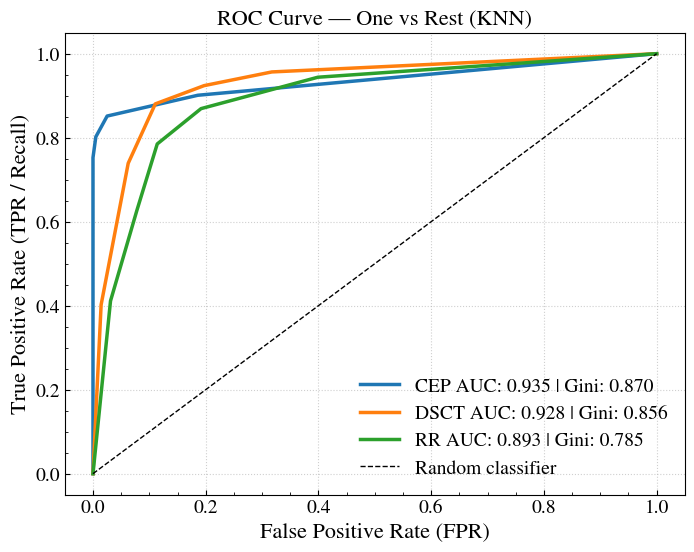

Clase                   AUC   Gini
-----------------------------------
CEP                   0.935  0.870
DSCT                  0.928  0.856
RR                    0.893  0.785


In [9]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


classes   = knn.classes_
n_classes = len(classes)

print(f"Evaluation for {n_classes} classes: {classes}")

# The ROC curve requires a binary format for the labels (One-vs-Rest) for each class.
# Transform 'CEP' -> [1, 0, 0], 'RR' -> [0, 1, 0], 'DSCT' -> [0, 0, 1]

y_test_bin = label_binarize(y_test, classes=classes)
print("\nBinary Labels")

print(f"Shape: {y_test_bin.shape} (Sample: {y_test_bin.shape[0]}, Classes: {y_test_bin.shape[1]})")
print(f'Example of binary labels (first 5 rows):\n{y_test_bin[:5]}')

# Probabilidades predichas (necesario para ROC)
y_prob = knn.predict_proba(X_test)

# Calcular ROC y AUC por clase
fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, color_classes.values())):
    # Compute FPR, TPR and thresholds for the current class
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    gini    = 2 * roc_auc - 1
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f'{cls} AUC: {roc_auc:.3f} | Gini: {gini:.3f}')

# Línea de clasificador aleatorio
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')

ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR / Recall)')
ax.set_title('ROC Curve — One vs Rest (KNN)')
ax.legend(frameon=False,loc='lower right')
ax.grid()

plt.show()

# Resumen numérico
print(f"{'Clase':<20} {'AUC':>6} {'Gini':>6}")
print("-" * 35)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    print(f"{cls:<20} {roc_auc:>6.3f} {2*roc_auc-1:>6.3f}")

## Decision Tree 

A Decision Tree is a non-parametric supervised learning algorithm that performs classification by recursively partitioning the feature space into disjoint rectangular regions. Each internal node represents a "test" on an attribute (e.g., Is absolute magnitude $M_G < 4.0$?), each branch represents the outcome of the test, and each leaf node represents a final class label (e.g., RR Lyrae).

The algorithm uses a Greedy Approach called Recursive Binary Splitting. At each node, it evaluates all possible features ($M_G$, $BP-RP$, $\varpi$, etc.) and all possible threshold values ($v$) to find the split that results in the "purest" child nodes.The goal is to move from a state of high uncertainty (a mix of all star types) to a state of high certainty (nodes containing only one type of star).

**Gini Impurity:** The default criterion for most implementations (including `scikit-learn`) is Gini Impurity. It measures the probability of a randomly chosen element from the set being incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.For a node with $C$ classes, the Gini Impurity $G$ is defined as:

$$G = 1 - \sum_{c=1}^{C} p_c^2$$

$$G_{max} = 1 - C \cdot \left(\frac{1}{C}\right)^2 = 1 - \frac{1}{C}$$

Example for your 3 classes: $G_{max} = 1 - \frac{1}{3} = 0.666$. If you see this value in a node, the model has no idea what that star is.

Where $p_c$ is the proportion of samples belonging to class $c$ in that specific node.
- $G = 0$: A "pure" node. All stars belong to the same class (e.g., 100% Cepheids).
- $G$ is maximized: When classes are perfectly mixed (e.g., 33% of each for 3 classes).

**Entropy (Information Theory):** An alternative to Gini is Entropy, which originates from Shannon's Information Theory. It measures the average "information" or "uncertainty" contained in the data.

The Entropy H of a node is calculated as:

$$H = - \sum_{c=1}^{C} p_c \log_2(p_c)$$

To decide the best split, the algorithm calculates the Information Gain (IG), which is the reduction in entropy achieved by partitioning the data according to a feature f:

$$IG(parent, f) = H(parent) - \sum_{i=1}^{k} \frac{N_i}{N_{total}} H(child_i)$$

The main hyperparameter controlling model complexity is `max_depth` — the maximum number of successive splits allowed. Without a limit, the tree will grow until every leaf is pure, **memorizing the training data** (overfitting).

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

# Evaluate
y_pred_dtree = dtree.predict(X_test)
print(classification_report(y_test, y_pred_dtree))


              precision    recall  f1-score   support

         CEP       0.99      0.87      0.93       101
        DSCT       0.92      0.74      0.82        92
          RR       0.74      0.94      0.83       107

    accuracy                           0.86       300
   macro avg       0.88      0.85      0.86       300
weighted avg       0.88      0.86      0.86       300



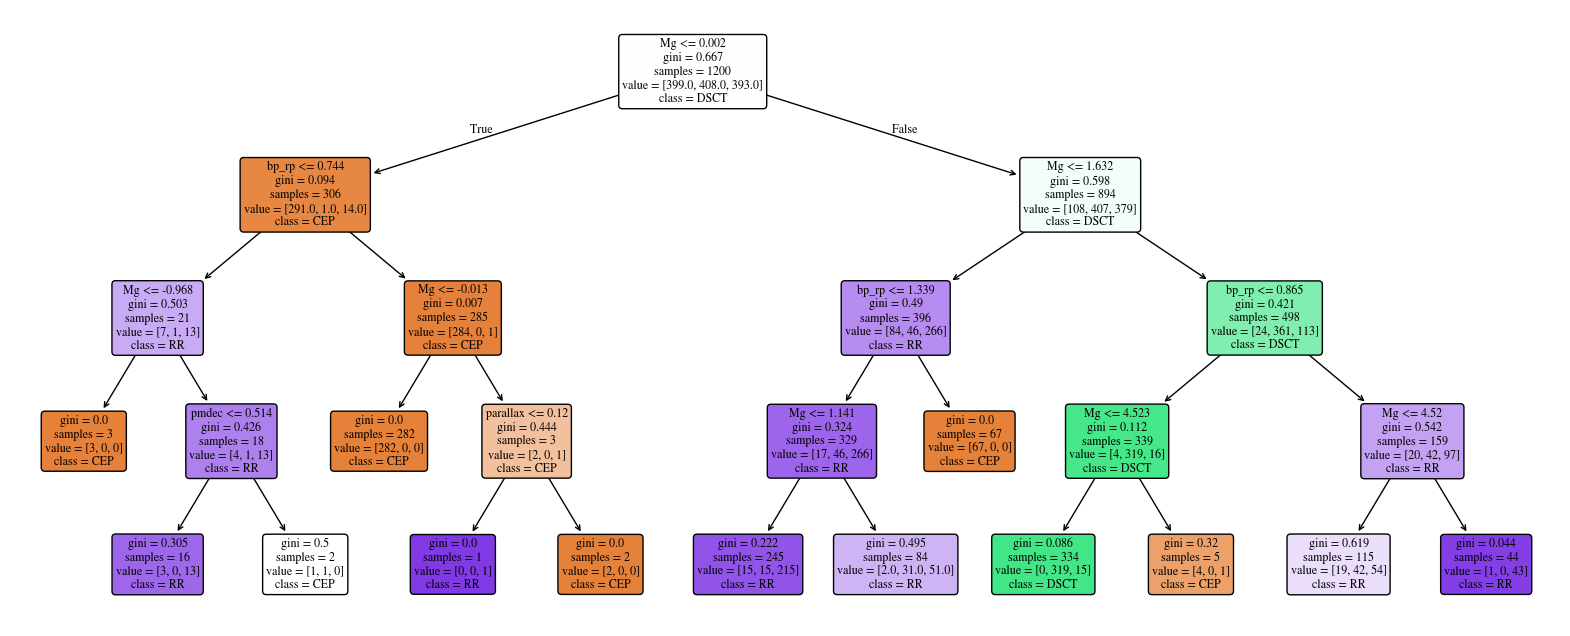

--- Rastro de decisión para la estrella 1169 ---
Nodo  0: ¿Mg > 0.0022? (Valor real: 0.2843) -> Vamos por la derecha
Nodo 12: ¿Mg ≤ 1.6320? (Valor real: 0.2843) -> Vamos por la izquierda
Nodo 13: ¿bp_rp ≤ 1.3393? (Valor real: 0.6282) -> Vamos por la izquierda
Nodo 14: ¿Mg ≤ 1.1409? (Valor real: 0.2843) -> Vamos por la izquierda
--> Nodo Hoja 15: Clasificación final = RR


In [11]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dtree,
          feature_names=X.columns.tolist(),
          class_names=dtree.classes_,
          filled=True,
          rounded=True,
          ax=ax)
plt.show()

# Select one objet from the test set to analyze its path through the tree
sample_idx = np.random.randint(0, len(X_test))  # You can change this index to select a different sample
sample = X_test.iloc[sample_idx:sample_idx+1]
node_indicator = dtree.decision_path(sample)
leaf_id = dtree.apply(sample) # El nodo final (hoja)
node_indices = node_indicator.indices

print(f"--- Rastro de decisión para la estrella {y_test.index[sample_idx]} ---")

# 2. Iterar sobre los nodos del camino
for node_id in node_indices:
    # Si el nodo es una hoja, terminamos
    if leaf_id[0] == node_id:
        print(f"--> Nodo Hoja {node_id}: Clasificación final = {dtree.predict(sample)[0]}")
        break

    # Obtener la regla del nodo
    feature = dtree.tree_.feature[node_id]
    threshold = dtree.tree_.threshold[node_id]
    feature_name = X.columns[feature]
    value = sample.values[0][feature]

    # Determinar si fue por la izquierda (True) o derecha (False)
    if value <= threshold:
        direction = "≤"
        next_step = "izquierda"
    else:
        direction = ">"
        next_step = "derecha"

    print(f"Nodo {node_id:2}: ¿{feature_name} {direction} {threshold:.4f}? "
          f"(Valor real: {value:.4f}) -> Vamos por la {next_step}")

One key advantage of Decision Trees over KNN is their ability to quantify **how much each feature contributes to the classification**. This is known as *feature importance* (or *Gini importance*).

Every time a node splits on feature $f$, the impurity of the data decreases. The importance of feature $f$ is the **total weighted Gini reduction** it roduces across all nodes in the tree:

$$\text{importance}(f) = \sum_{\substack{t \in \text{nodes} \\ \text{split on } f}} \frac{N_t}{N} \,\Delta G_t$$

where $N_t$ is the number of samples reaching node $t$, $N$ is the total number of training samples, and $\Delta G_t$ is the Gini reduction at that node:

$$\Delta G_t = G_t - \frac{N_L}{N_t} G_L - \frac{N_R}{N_t} G_R$$

with $L$ and $R$ denoting the left and right child nodes respectively.

The importances are then **normalized** so that they sum to 1:

$$\sum_{f} \text{importance}(f) = 1$$

**Interpreting the values:**
- A feature with high importance → the tree relies heavily on it to separate classes
- A feature with near-zero importance → it adds little discriminating power and could potentially be removed

In our stellar classification problem, we expect $M_G$ (absolute magnitude) and $BP-RP$ (color) to dominate, since they directly locate a star on the HR diagram within the instability strip. Proper motions ($\mu_\alpha$, $\mu_\delta$) and parallax ($\varpi$) may provide secondary separation between populations of different ages and kinematics (e.g., old halo RR Lyrae vs. young disk Cepheids).

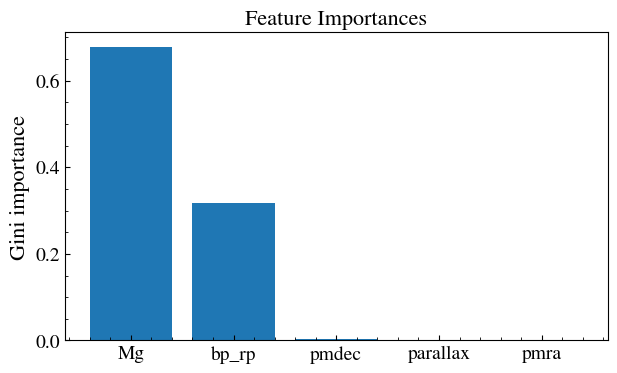

In [13]:
importances = dtree.feature_importances_
indices     = np.argsort(importances)[::-1]

plt.figure(figsize=(7, 4))
plt.bar(X.columns[indices], importances[indices])
plt.title("Feature Importances")
plt.ylabel("Gini importance")
plt.show()

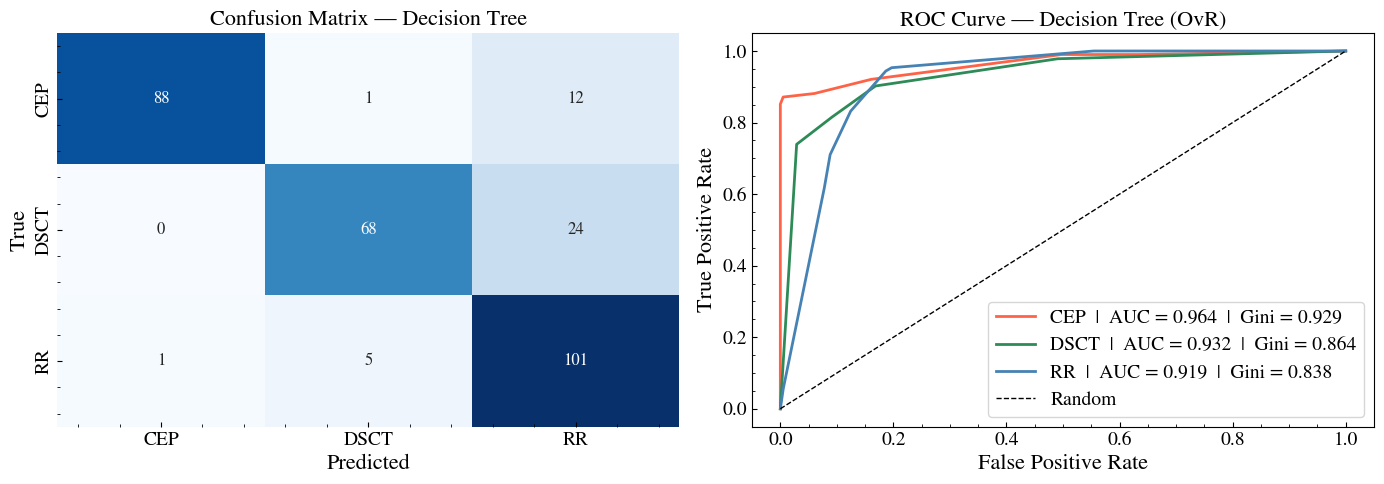

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 1. CONFUSION MATRIX ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_dtree, labels=dtree.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=dtree.classes_, yticklabels=dtree.classes_,
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix — Decision Tree')

# ── 2. ROC CURVE (One-vs-Rest) ───────────────────────────────────
y_test_bin = label_binarize(y_test, classes=dtree.classes_)
y_prob_dtree  = dtree.predict_proba(X_test)

colors = ['tomato', 'seagreen', 'steelblue']

for i, (cls, color) in enumerate(zip(dtree.classes_, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dtree[:, i])
    roc_auc     = auc(fpr, tpr)
    gini        = 2 * roc_auc - 1
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'{cls}  |  AUC = {roc_auc:.3f}  |  Gini = {gini:.3f}')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Decision Tree (OvR)')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## Why Random Forest over a Single Decision Tree?

A single Decision Tree, if grown without constraints, will **perfectly classify every training sample** — it simply memorizes the data. This is the classical overfitting problem: the model fits noise rather than the underlying signal, and generalizes poorly to new observations.

### The Core Problem: High Variance

A Decision Tree is a **high-variance** estimator. A small change in the training set (e.g., removing a few stars or adding new ones) can produce a completely different tree structure. This instability makes a single tree an unreliable classifier for scientific applications such as building stellar catalogs.

### The Solution: Ensemble Learning via Bagging

Random Forest addresses this by combining $B$ independent trees, each trained on a **bootstrap sample** — a random subset of the training data drawn *with replacement*:

$$\hat{y}(\mathbf{x}) = \underset{c}{\arg\max} \sum_{b=1}^{B} \mathbf{1}
\left[ T_b(\mathbf{x}) = c \right]$$

where $T_b(\mathbf{x})$ is the prediction of the $b$-th tree. The final class is determined by **majority vote** across all $B$ trees.

This technique is called **Bagging** (Bootstrap AGGregatING), and it reduces variance without significantly increasing bias:

$$\text{Var}\!\left(\frac{1}{B}\sum_{b=1}^B T_b\right) \approx \frac{\rho\,\sigma^2}{B}$$

where $\sigma^2$ is the variance of a single tree and $\rho$ is the correlation between trees. This shows two things:
- More trees ($B \uparrow$) → lower variance
- Less correlated trees ($\rho \downarrow$) → lower variance

### The Extra Trick: Random Feature Subsampling

To decorrelate the trees, at each split Random Forest only considers a **random subset of $m$ features** (instead of all $p$ features):

$$m \approx \sqrt{p} \quad \text{(classification default)}$$

This prevents all trees from always splitting on the same dominant feature (e.g., $M_G$), forcing them to explore different regions of the feature space and producing more diverse, less correlated trees.

### Decision Tree vs. Random Forest

| Property | Decision Tree | Random Forest |
|---|---|---|
| Variance | High | Low |
| Bias | Low | Low |
| Overfitting risk | High | Low |
| Interpretability | High (visualizable) | Low (black box) |
| Feature importance | Yes (single path) | Yes (averaged, more robust) |
| Training cost | Low | Higher ($\times B$) |

In our stellar classification context, Random Forest is preferred because a single tree may draw its boundaries based on statistical fluctuations in the Gaia sample (noisy parallaxes, crowded fields), whereas averaging over hundreds of trees produces a **more stable classification of the instability strip**.

Beyond the methods covered in this notebook, scikit-learn offers a wide range of supervised classification algorithms, each occupying a different position in the **bias–variance tradeoff** and making different trade-offs between complexity, interpretability, and computational cost.

A summary:

| Method | Bias | Variance | Interpretability | Cost |
|---|---|---|---|---|
| Logistic Regression | High | Low | High | Low |
| K-Nearest Neighbors | Low | High | Medium | Low (train) / High (predict) |
| Decision Tree | Low | High | High | Low |
| Random Forest | Low | Low | Low | Medium |
| Support Vector Machine | Medium | Low | Low | High |
| Gradient Boosting (XGBoost) | Low | Low | Low | High |
| Neural Network | Low | Low | Very Low | Very High |

We encourage you to explore the full list of classifiers and their hyperparameters in the official scikit-learn documentation:
[https://scikit-learn.org/stable/supervised_learning.html](https://scikit-learn.org/stable/supervised_learning.html)

In [27]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Definimos el esquema de validación: 5 divisiones (Folds)
# Shuffle=True es vital para asegurar que los datos no estén ordenados
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Usamos el dataset original balanceado (X, y definido anteriormente)
clf_cv = RandomForestClassifier(n_estimators=100, random_state=42)

# Calculamos la exactitud para cada uno de los 5 experimentos
scores = cross_val_score(clf_cv, X, y, cv=skf, scoring='accuracy')

print("--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLD) ---")
print(f"Exactitudes por Fold: {scores}")
print(f"Exactitud Promedio: {scores.mean():.4f} +/- {scores.std():.4f}")

# Esto demuestra la estabilidad del modelo ante diferentes subconjunt

--- RESULTADOS DE VALIDACIÓN CRUZADA (5-FOLD) ---
Exactitudes por Fold: [0.95  0.96  0.985 0.97  0.945]
Exactitud Promedio: 0.9620 +/- 0.0144


Ranking de simplicidad en sklearn:

Modelo	Parámetros mínimos	Explicabilidad
KNN	1 (k)	Alta
Decision Tree	1 (max_depth)	Alta
Logistic Regression	1 (C)	Media
Random Forest	2+	Media
SVM	2+	Baja
Para un auxiliar de ML supervisado, KNN o Decision Tree son los mejores puntos de partida antes de introducir modelos más complejos.